## Imports



In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
#from tqdm.notebook import tqdm
from tqdm import tqdm
import seaborn as sns # Great for histograms

from performance_boosting import PBClosedLoop, PBLoss, PinballLossWrapper, CVaRLossWrapper
from ren import ContractiveREN
from robot import RobotPlant, ProportionalController, StabilizedRobot
from plot_functions import plot_pb_trajectories
from batch_generation import generate_random_batch

## Simulation parameters

In [ ]:
#setup device
device = torch.device("cpu")
print(f"Using device: {device}")

#seed
seed = 1

# --- 1.Physics Parameters ---
#disturbance parameters
x0_std = 0.2
noise_std = 0.

#controller parameters
kp = 1.

#physics parameters
n_agents = 1
state_dim = 4
input_dim = 2
dt = 0.05

#nominal model parameters
b_nom = 1
m_nom = 1
b2_nom = 0.2

#simulator parameters
b_sim = 1
m_sim = 1
b2_sim = 0.2

#ren parameters
initialization_std = 0.1
dim_internal = 4
dim_nl = 4

# --- 2. Loss Parameters (Q and R) ---
# Base Q for 1 agent: Penalize pos_x, pos_y, vel_x, vel_y shape (4, 4)
alpha_x = 1
Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * alpha_x
# Expand Q for N agents (Block Diagonal): (4 * n_agents, 4 * n_agents)
Q = torch.kron(torch.eye(n_agents), Q_agent)

# Base R for 1 agent: Penalize force_x, force_y shape (2, 2)
alpha_u = 0.0002
R_agent = torch.eye(2) * alpha_u
# Expand R for N agents: (2 * n_agents, 2 * n_agents)
R = torch.kron(torch.eye(n_agents), R_agent)

# Weight for obstacle avoidance
alpha_obs = 100.0

# --- 3. Obstacles Parameters ---
obs_centers = [torch.tensor([-0.5, -0.5])]
obs_sigmas  = [torch.tensor([0.2, 0.2])]

# --- 4. Target State: All agents to go to origin (0,0) with 0 velocity.
x_target = torch.zeros(4 * n_agents)

#------ 5. Wrapper Parameters----------
cvar_wrapper = True
pinball_wrapper = not cvar_wrapper
conditional_training = False
#true certification goals
alpha_true = 0.05       # Probability threshold w/r draw of calibration data
delta = 0.05            # Probability threshold w/r nonconformity score violation
m_cert = 1000          # Size of certification dataset (large because pseudo-conditional)
#Calculate the shift in alpha for conditional certificates
if conditional_training:
    epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert))
else:
    epsilon_cert = 0
# Shift training alpha
alpha_train = alpha_true - epsilon_cert

#--------6. training parameters------------
num_training_steps = 2000
log_interval = 50 # Evaluate and print every 50 steps
batch_size = 50
horizon = 300
lr = 0.001

Using device: cpu


## Set seed

In [3]:
seed = seed  # Choose any fixed number
torch.manual_seed(seed)
np.random.seed(seed)

## Initialize fixed validation set

In [ ]:
# Fixed validation set to track performance during training
fixed_val_w = generate_random_batch(batch_size=50, horizon=horizon, n_agents=n_agents,
                                    x0_std=x0_std, noise_std=noise_std, device=device)

## Simulator, nominal model and stabilizing controller

In [6]:
#Open loop real plant (unknown)
sim_OL_plant = RobotPlant(b = b_sim, b2 = b2_sim, m = m_sim, n_agents = n_agents).to(device)
#Open loop nominal model
nominal_OL_plant = RobotPlant(b = b_nom, b2 = b2_nom, m = m_nom, n_agents = n_agents).to(device)
#Proportional controller
base_controller = ProportionalController(kp = kp, n_agents = n_agents).to(device)
#Stabilized real plant (closed loop of real plant and base controller) (unknown)
f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(device)
#Stabilized nominal model (closed loop of nominal model and base controller) (I could use a different controller as long as this is a stable closed loop or if I use the base controller of the real plant I have to make sure it stabilizes my model as well)
f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(device)

#Freeze the physics/nominal models
for param in f_sim.parameters():
    param.requires_grad = False
for param in f_nom.parameters():
    param.requires_grad = False

## Empirical Risk Minimization training (no model mismatch)


### Define simulated model

In [7]:
#Ren
ren = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim = PBClosedLoop(ren, f_sim, f_nom).to(device)

### Training loop


Starting online training on cpu...


Training Steps: 100%|██████████| 2000/2000 [06:13<00:00,  5.35it/s, Train Loss=0.7328, Val Loss=0.6599]


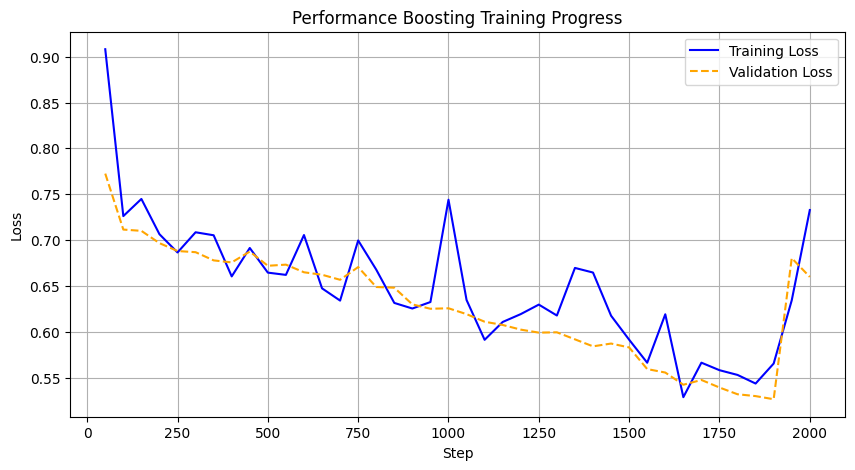

In [ ]:
#Instantiate loss and Move to Device
loss_fn = PBLoss(x_target, Q, R, alpha_obs=alpha_obs,
                 obs_centers=obs_centers, obs_sigmas=obs_sigmas, n_agents=n_agents)
loss_fn.to(device) #Moves Q, R, target, and obstacles to GPU

optimizer = torch.optim.Adam(PB_closed_loop_sim.parameters(), lr=lr)

# Lists for plotting
train_losses = []
val_losses = []

# Only store the very last batch's trajectories for plotting to save RAM
last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online training on {device}...")

# Use tqdm for a nice progress bar
pbar = tqdm(range(num_training_steps), desc="Training Steps")

for step in pbar:
    # --- TRAINING PHASE ---
    PB_closed_loop_sim.train()
    optimizer.zero_grad()

    # 1. Generate fresh data
    batch_w = generate_random_batch(batch_size, horizon, n_agents, x0_std, noise_std, device)

    # 2. Run Sim & Compute Loss
    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim.run(batch_w)
    loss, _, _, _ = loss_fn(traj_x_train, traj_u_train)

    # 3. Backprop
    loss.backward()
    optimizer.step()

    # --- VALIDATION & LOGGING ---
    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim.eval()

        with torch.no_grad():
            # Evaluate on FIXED validation set
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim.run(fixed_val_w)
            val_loss, _, _, _ = loss_fn(traj_x_val, traj_u_val)

        # Update lists for plotting
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        # Update progress bar metrics
        pbar.set_postfix({
            'Train Loss': f"{loss.item():.4f}",
            'Val Loss': f"{val_loss.item():.4f}"
        })

    # Only save the validation trajectories on the very last step to prevent RAM overload
    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

# --- PLOTTING ---
plt.figure(figsize=(10, 5))
plt.plot(range(log_interval, num_training_steps + 1, log_interval), train_losses, label='Training Loss', color='blue')
plt.plot(range(log_interval, num_training_steps + 1, log_interval), val_losses, label='Validation Loss', color='orange', linestyle='--')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Performance Boosting Training Progress')
plt.legend()
plt.grid(True)
plt.show()

### Save Model

In [9]:
# Save standard model + optimizer
torch.save({
    "ren_state": ren.state_dict(),
    "optimizer_state": optimizer.state_dict(),
}, "ren_standard_checkpoint.pt")

### Plots


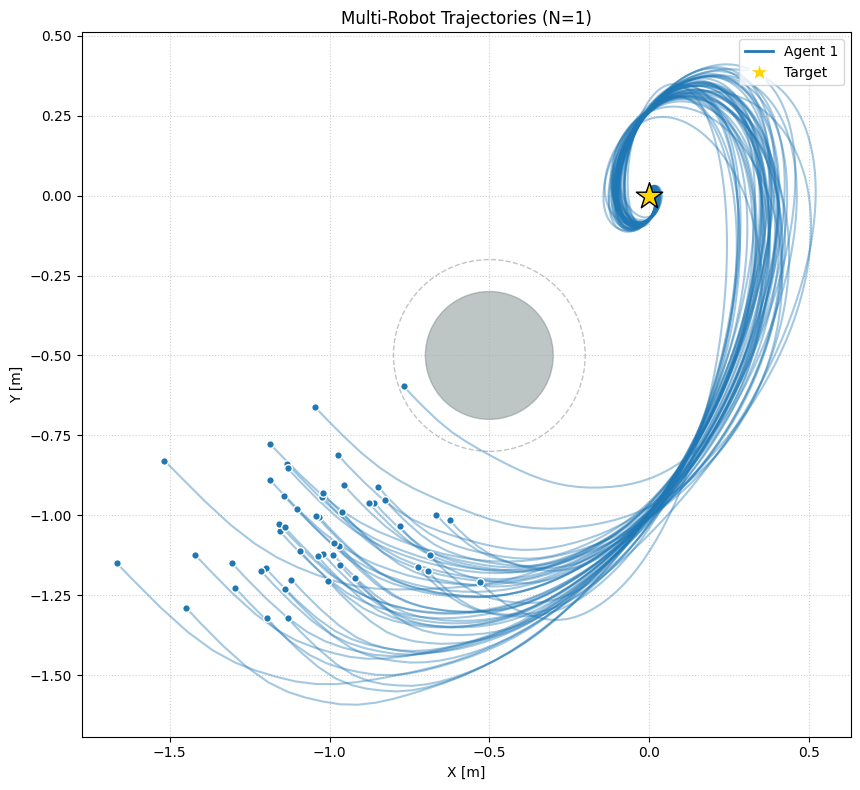

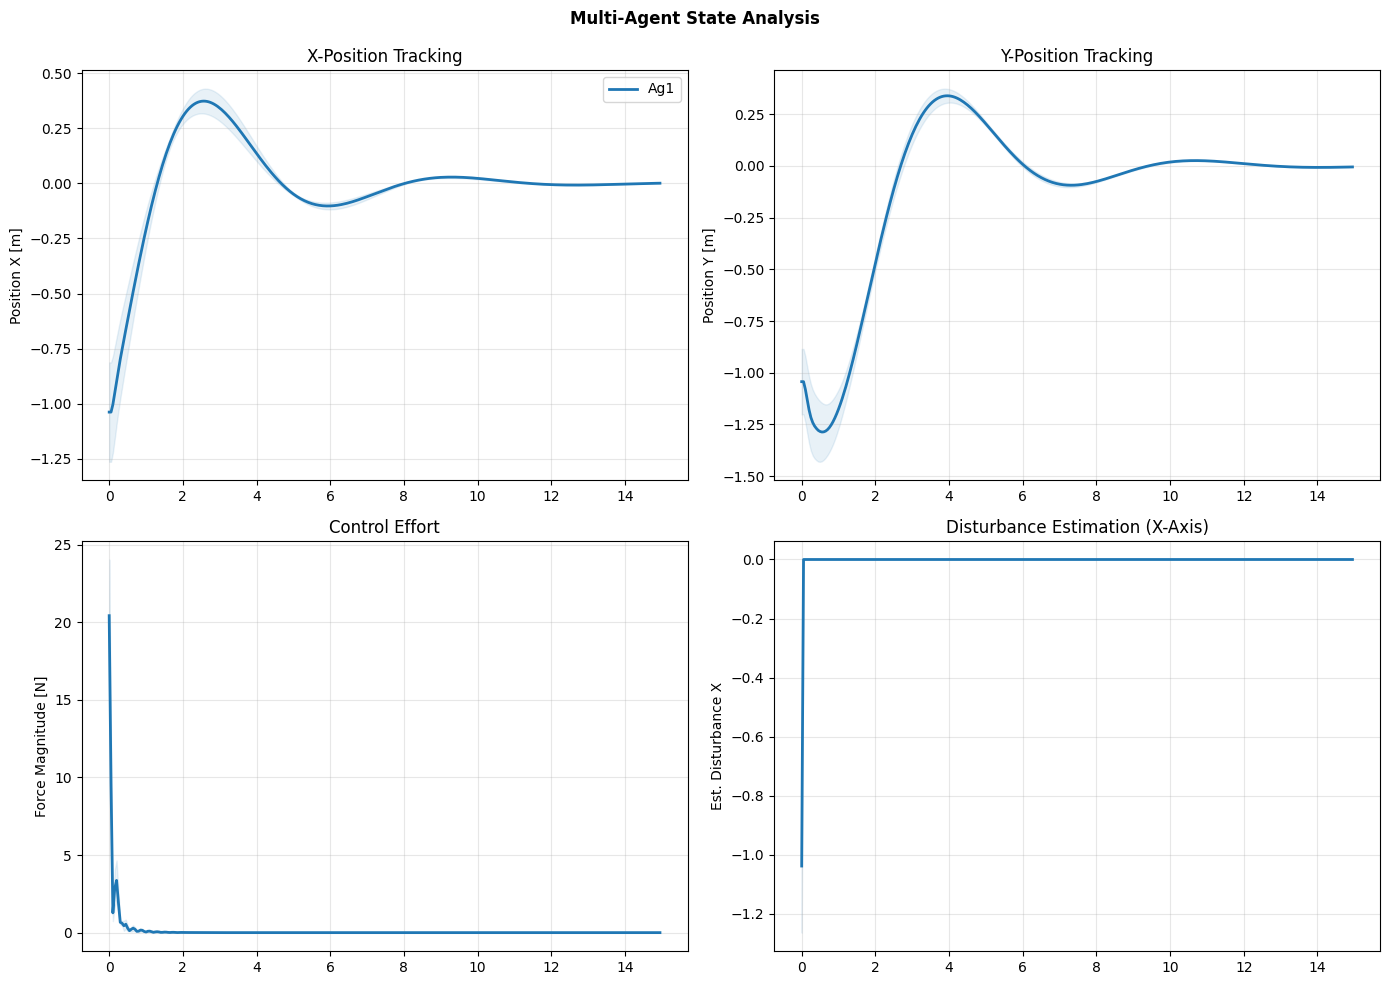

In [10]:
plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt
)

## Quantile-oriented training

### Define simulated model

In [11]:
#Ren
ren_quantile = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_quantile = PBClosedLoop(ren_quantile, f_sim, f_nom).to(device)

### Training loop

Starting online training on cpu...


CVaR Training Steps: 100%|██████████| 2000/2000 [06:14<00:00,  5.34it/s, CVaR Train=0.8786, CVaR Val=1.2038, Tau=0.8353] 


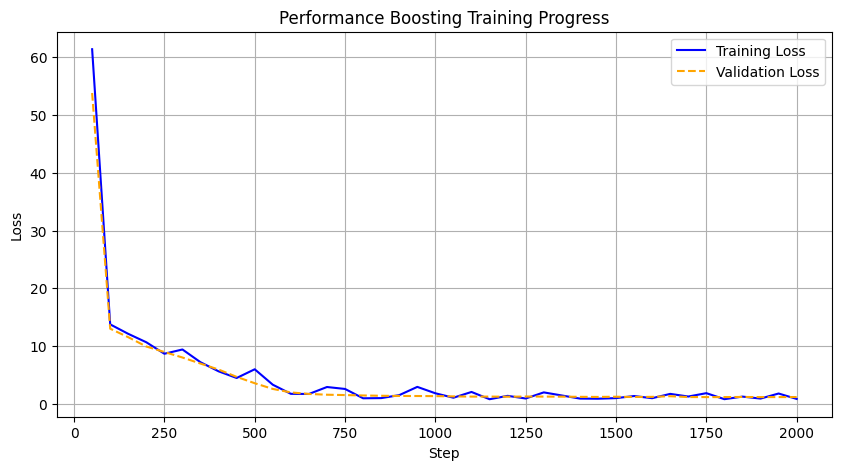

In [ ]:
#Instantiate metric and Move to Device
metric = PBLoss(x_target, Q, R, alpha_obs=alpha_obs,
                 obs_centers=obs_centers, obs_sigmas=obs_sigmas, n_agents=n_agents)

metric.to(device)  #Moves Q, R, target, and obstacles to GPU

# 1. Setup Loss Wrapper
if cvar_wrapper:
    loss_wrapper = CVaRLossWrapper(alpha=alpha_train, metric=metric)
elif pinball_wrapper:
    loss_wrapper = PinballLossWrapper(alpha=alpha_train, metric=metric)
loss_wrapper.to(device) # Moves tau to GPU

# We must optimize controller and tau (threshold) simultaneously
optimizer = torch.optim.Adam(
    list(PB_closed_loop_sim_quantile.parameters()) + [loss_wrapper.tau],
    lr=lr
)

# Lists for plotting
train_losses = []
val_losses = []

# Only store the very last batch's trajectories for plotting to save RAM
last_traj_x_train = None
last_traj_u_train = None
last_traj_w_hat_train = None

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online training on {device}...")

# Use tqdm for a nice progress bar
pbar = tqdm(range(num_training_steps), desc="CVaR Training Steps")

for step in pbar:
    PB_closed_loop_sim_quantile.train()
    optimizer.zero_grad()

    batch_w = generate_random_batch(batch_size, horizon, n_agents, x0_std, noise_std, device)

    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_quantile.run(batch_w)
    # Wrapper returns (loss, raw_costs)
    loss, _ = loss_wrapper(traj_x_train, traj_u_train)

    loss.backward()
    optimizer.step()

    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_quantile.eval()

        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_quantile.run(fixed_val_w)
            val_loss, _ = loss_wrapper(traj_x_val, traj_u_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        pbar.set_postfix({
            'CVaR Train': f"{loss.item():.4f}",
            'CVaR Val': f"{val_loss.item():.4f}",
            'Tau': f"{loss_wrapper.tau.item():.4f}" # Log Tau!
        })

    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

# --- PLOTTING ---
plt.figure(figsize=(10, 5))
plt.plot(range(log_interval, num_training_steps + 1, log_interval), train_losses, label='Training Loss', color='blue')
plt.plot(range(log_interval, num_training_steps + 1, log_interval), val_losses, label='Validation Loss', color='orange', linestyle='--')
plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Performance Boosting Training Progress')
plt.legend()
plt.grid(True)
plt.show()

### Save Model

In [13]:
# Save standard model + optimizer
torch.save({
    "ren_state": ren.state_dict(),
    "optimizer_state": optimizer.state_dict(),
}, "ren_cvar_checkpoint.pt")

### Plots


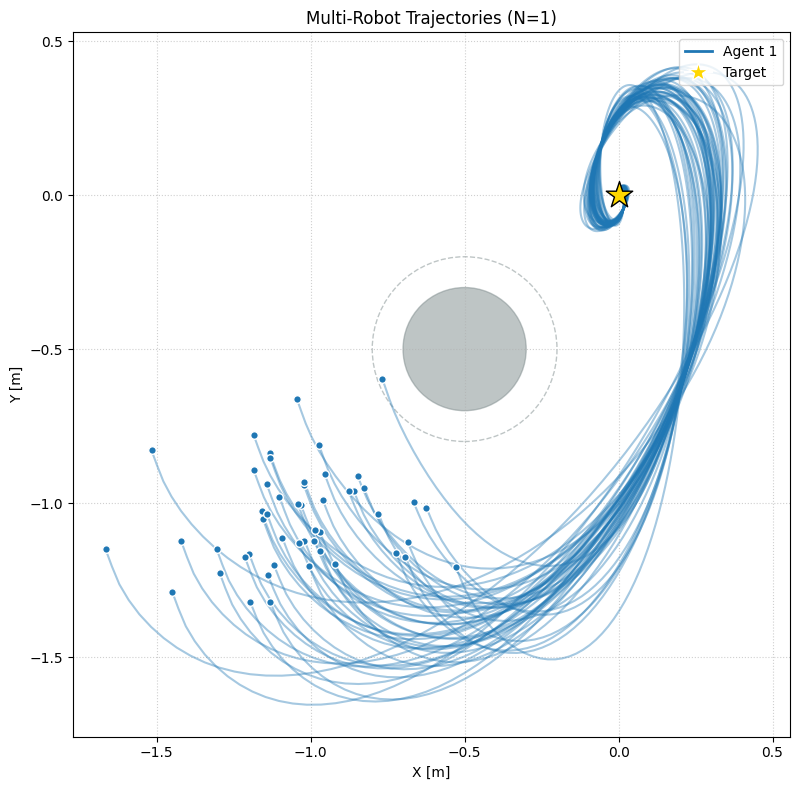

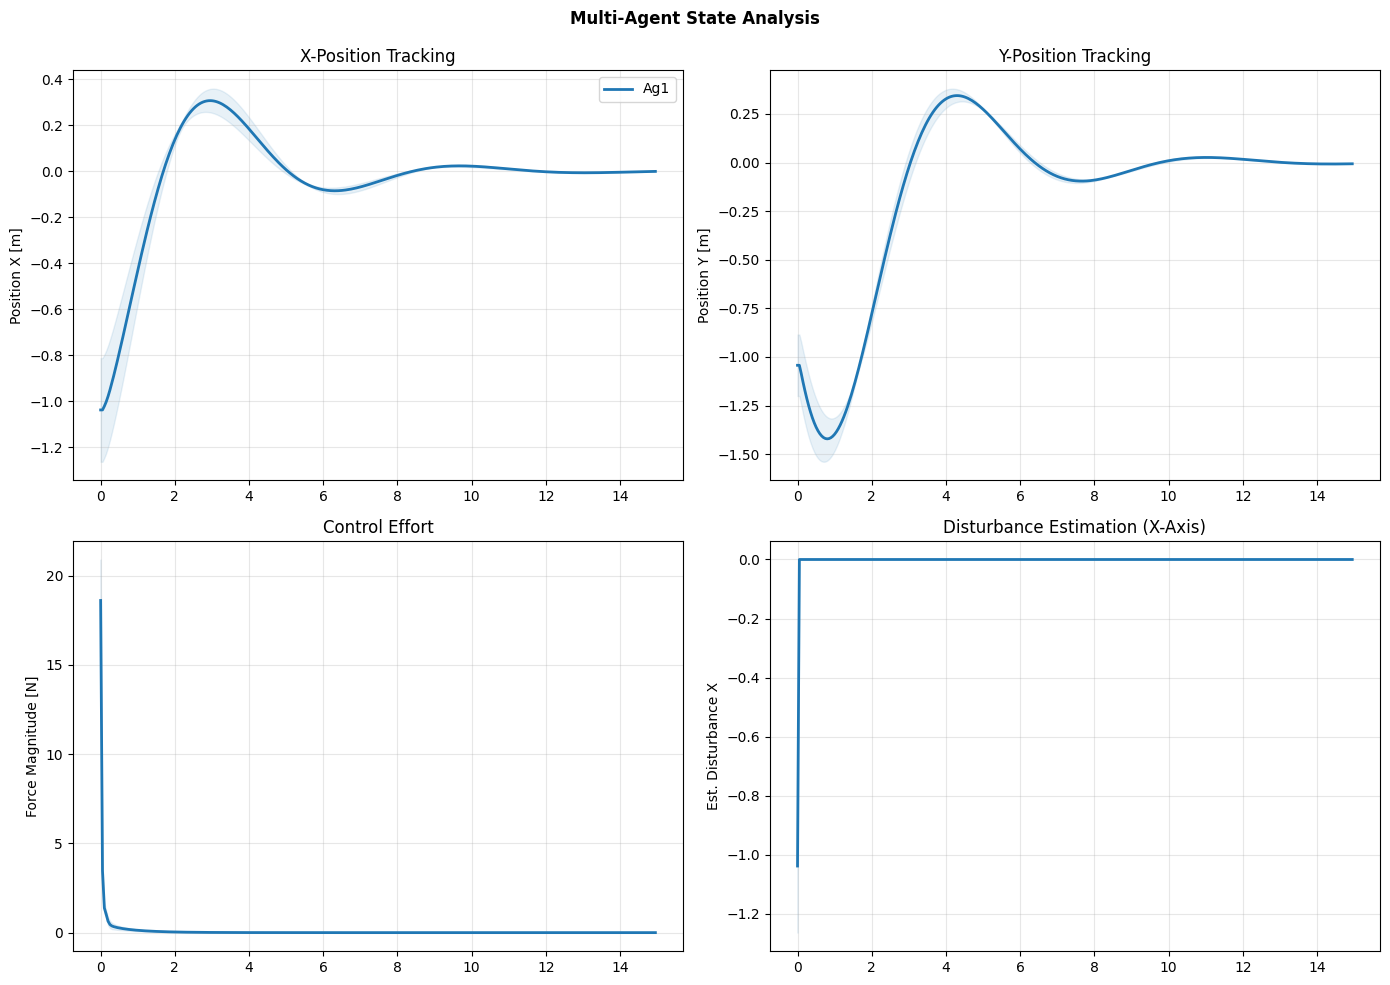

In [14]:
plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_sigma=obs_sigmas,
    dt=dt
)

## Comparison test

--- Standard (Average) Controller ---
Mean Cost:       0.6769
95% Quantile:    0.9541
CVaR (Worst 5%): 1.3839
Absolute Worst:  3.5606

--- Robust (CVaR) Controller ---
Mean Cost:       0.6966
95% Quantile:    0.8846
CVaR (Worst 5%): 1.1636
Absolute Worst:  3.2750



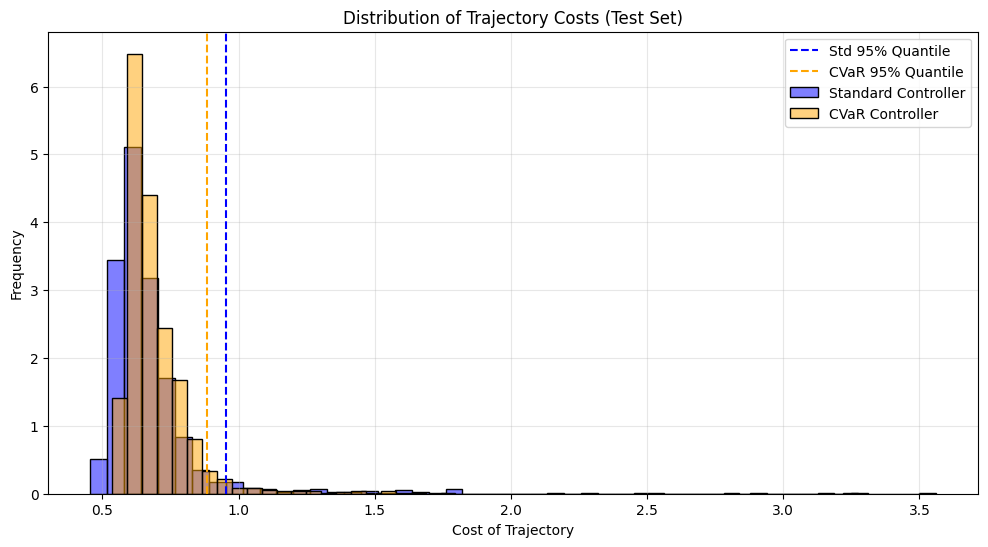

In [ ]:
# 1. Generate a fixed test set
num_test_samples = 2000
test_w = generate_random_batch(num_test_samples, horizon, n_agents, x0_std, noise_std, device)

# 2. Evaluate Standard Controller
PB_closed_loop_sim.eval()
with torch.no_grad():
    traj_x_std, traj_u_std, _ = PB_closed_loop_sim.run(test_w)
    # Get the vector of costs (one per trajectory)
    costs_std = metric.compute_per_sample_cost(traj_x_std, traj_u_std).cpu().numpy()

# 3. Evaluate CVaR Controller
PB_closed_loop_sim_quantile.eval()
with torch.no_grad():
    traj_x_cvar, traj_u_cvar, _ = PB_closed_loop_sim_quantile.run(test_w)
    costs_cvar = metric.compute_per_sample_cost(traj_x_cvar, traj_u_cvar).cpu().numpy()

# 4. Compute some statistic of metrics
def print_metrics(name, costs, alpha=0.05):
    mean_cost = np.mean(costs)
    max_cost = np.max(costs)
    # The value below which 95% of the data falls
    quantile_95 = np.quantile(costs, 1 - alpha)
    # Average of the worst 5%
    cvar_95 = np.mean(costs[costs >= quantile_95])

    print(f"--- {name} ---")
    print(f"Mean Cost:       {mean_cost:.4f}")
    print(f"95% Quantile:    {quantile_95:.4f}")
    print(f"CVaR (Worst 5%): {cvar_95:.4f}")
    print(f"Absolute Worst:  {max_cost:.4f}\n")

print_metrics("Standard (Average) Controller", costs_std)
print_metrics("Robust (CVaR) Controller", costs_cvar)

# 5. Plot the Distribution of Costs
plt.figure(figsize=(12, 6))
sns.histplot(costs_std, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density')
sns.histplot(costs_cvar, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density')

plt.axvline(np.quantile(costs_std, 0.95), color='blue', linestyle='dashed', label='Std 95% Quantile')
plt.axvline(np.quantile(costs_cvar, 0.95), color='orange', linestyle='dashed', label='CVaR 95% Quantile')

plt.title("Distribution of Trajectory Costs (Test Set)")
plt.xlabel("Cost of Trajectory")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()